# Fitting force constants in Python

This notebook repeats the force-constant fits of the Si tutorial with the `alm` Python module
instead of the `alm` program:

1. build the model of a $2\times2\times2$ conventional supercell (64 atoms) of Si,
2. fit the harmonic force constants by ordinary least squares (OLS),
3. fit the cubic force constants with the harmonic ones fixed,
4. look at the fitting errors,
5. fit the same cubic model with a scikit-learn regressor (LassoCV),
6. save the result as an `.h5` file that *anphon* reads,
7. plot the harmonic force constants against the interatomic distance.

It needs the compiled `alm` module (see *ALM Python interface* in the ALAMODE documentation),
so run it in a local ALAMODE checkout after installing the module, or on Binder, where it is built for you.
The displacement-force data are the `DFSET` files of `example/Si/reference/` (Quantum ESPRESSO, atomic units).

In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np

import alm

%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 90

SI = os.path.join("..", "Si")            # example/Si of the ALAMODE source tree

## 1. Structure and data

We take the 64-atom supercell from the tutorial input `example/Si/si_alm.in` (lattice constant 20.406 bohr).
`ALM` works in atomic units by default: lattice vectors in bohr (one vector per row),
displacements in bohr, and forces in Ry/bohr.

A `DFSET` file has one line `ux uy uz fx fy fz` per atom, for all snapshots one after the other.

In [2]:
text = open(os.path.join(SI, "si_alm.in")).read()
block = re.search(r"&position(.*?)/", text, re.S).group(1)
xcoord = np.array([[float(v) for v in line.split()[1:4]] for line in block.splitlines() if line.strip()])
nat = len(xcoord)
lavec = 20.406 * np.eye(3)               # bohr
numbers = [14] * nat                     # atomic numbers (Si)

def read_dfset(filename, nat):
    '''Return displacements and forces, each of shape (nsnap, nat, 3).'''
    data = np.loadtxt(filename).reshape(-1, nat, 6)
    return data[:, :, :3], data[:, :, 3:]

u2, f2 = read_dfset(os.path.join(SI, "reference", "DFSET_harmonic"), nat)
u3, f3 = read_dfset(os.path.join(SI, "reference", "DFSET_cubic"), nat)
print(f"{nat} atoms; {len(u2)} harmonic snapshot(s), {len(u3)} cubic snapshots")

64 atoms; 1 harmonic snapshot(s), 20 cubic snapshots


## 2. Harmonic force constants (OLS)

`define(1)` builds a harmonic model with no cutoff; `set_constraint()` imposes the acoustic sum rule
(`ICONST = 11` of the program). `optimize()` then solves the least-squares problem.
The relative fitting error is $\lVert F_\mathrm{fit} - F_\mathrm{DFT}\rVert / \lVert F_\mathrm{DFT}\rVert$;
we compute it from the sensing matrix $A$ and force vector $b$ returned by `get_matrix_elements()`.

In [3]:
fit2 = alm.ALM(lavec, xcoord, numbers)
fit2.define(1)                           # 1 = harmonic
fit2.set_constraint(translation=True)
fit2.set_training_data(u2, f2)
info = fit2.optimize()
print("solver info:", info, "| free parameters:", fit2.get_number_of_free_parameters())

def ols(A, b):
    return np.linalg.lstsq(A, b, rcond=None)[0]

A2, b2 = fit2.get_matrix_elements()
x2 = ols(A2, b2)
print(f"harmonic fitting error: {np.linalg.norm(A2 @ x2 - b2) / np.linalg.norm(f2):.4%}")

fc2_file = "si222_python_harmonic.h5"
fit2.save_fc(fc2_file, format="alamode_h5")

solver info: 0 | free parameters: 25
harmonic fitting error: 0.5672%


## 3. Cubic force constants (OLS)

As in the tutorial, the harmonic terms are fixed to the values just fitted (`FC2FIX`),
and the cubic terms are restricted to a cutoff radius of 7.3 bohr (second-nearest neighbors).
`cutoff_radii` has shape `(maxorder, nkd, nkd)`; a negative value means no cutoff.

With fixed harmonic terms, $b$ holds the forces minus the harmonic part, so the error is still normalized by the full DFT forces.

In [4]:
cutoff = np.array([[[-1.0]],             # harmonic: no cutoff
                   [[7.3]]])             # cubic: 7.3 bohr

fit3 = alm.ALM(lavec, xcoord, numbers)
fit3.fix_fc_from_file(1, fc2_file)       # 1 = harmonic
fit3.define(2, cutoff_radii=cutoff)      # 2 = up to cubic
fit3.set_constraint(translation=True)
fit3.set_training_data(u3, f3)
fit3.optimize()

A3, b3 = fit3.get_matrix_elements()
x3 = ols(A3, b3)
print(f"cubic model: {A3.shape[1]} free parameters, {A3.shape[0]} equations")
print(f"cubic fitting error: {np.linalg.norm(A3 @ x3 - b3) / np.linalg.norm(f3):.4%}")

cubic model: 27 free parameters, 3840 equations
cubic fitting error: 0.1461%


## 4. Fitting errors per snapshot

The residual per snapshot shows whether a few configurations dominate the error.

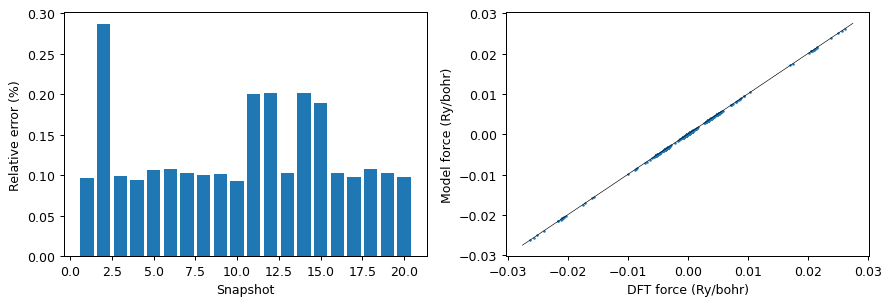

In [5]:
res = (A3 @ x3 - b3).reshape(len(u3), -1)
err = np.linalg.norm(res, axis=1) / np.linalg.norm(f3.reshape(len(f3), -1), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(np.arange(1, len(err) + 1), 100 * err)
axes[0].set_xlabel("Snapshot")
axes[0].set_ylabel("Relative error (%)")
fpred = (f3.ravel() - b3) + A3 @ x3      # harmonic part + fitted cubic part
axes[1].plot(f3.ravel(), fpred, ".", ms=2)
lim = np.abs(f3).max() * 1.05
axes[1].plot([-lim, lim], [-lim, lim], "k-", lw=0.5)
axes[1].set_xlabel("DFT force (Ry/bohr)")
axes[1].set_ylabel("Model force (Ry/bohr)")
fig.tight_layout()
plt.show()

## 5. An external regressor: LassoCV

`get_matrix_elements()` gives the exact linear problem $A x = b$ that ALM solves, so any regressor can fit it.
We normalize the columns of $A$ so that the $\ell_1$ penalty treats all parameters alike,
let `LassoCV` choose the penalty by 5-fold cross-validation, and inject the solution back with `set_fc()`.
Other scikit-learn models (`ARDRegression`, `BayesianRidge`, ...) are used the same way.

In [6]:
from sklearn.linear_model import LassoCV

col = np.linalg.norm(A3, axis=0)
col[col == 0] = 1.0
lasso = LassoCV(cv=5, fit_intercept=False, max_iter=100000).fit(A3 / col, b3)
x_lasso = lasso.coef_ / col

print(f"alpha chosen by CV: {lasso.alpha_:.2e}")
print(f"nonzero parameters: {np.sum(np.abs(x_lasso) > 1e-10)} of {len(x_lasso)}")
print(f"fitting error OLS:   {np.linalg.norm(A3 @ x3 - b3) / np.linalg.norm(f3):.4%}")
print(f"fitting error Lasso: {np.linalg.norm(A3 @ x_lasso - b3) / np.linalg.norm(f3):.4%}")

alpha chosen by CV: 1.08e-09
nonzero parameters: 17 of 27
fitting error OLS:   0.1461%
fitting error Lasso: 0.1474%


The cubic model of Si with a 7.3 bohr cutoff is small and well determined by the data,
so LASSO keeps the error of OLS and only removes parameters that are (nearly) zero.
Its advantage shows for large models with many more parameters, as in the BaTiO3 example of the documentation.

## 6. Save for *anphon*

`save_fc(..., format="alamode_h5")` writes the force-constant file that *anphon* reads through `FCSFILE`.

In [7]:
fit3.set_fc(x_lasso)
fit3.save_fc("si222_python_cubic.h5", format="alamode_h5")

import h5py
with h5py.File("si222_python_cubic.h5", "r") as f:
    print(f.attrs["schema"])
    for order in ("Order2", "Order3"):
        print(order, f[f"ForceConstants/{order}/force_constant_values"].shape)

alamode:force_constants
Order2 (1386,)
Order3 (2634,)


## 7. Harmonic force constants versus distance

`get_fc(1)` returns the harmonic force constants $\Phi_{\alpha\beta}(i, j)$ (Ry/bohr$^2$) with the first atom in the primitive cell,
together with the flattened indices $3i + \alpha$. We plot the largest element of each $3\times3$ block
against the distance between the atoms (minimum image in the supercell).
The force constants decay with distance, but not monotonically; pairs at the supercell boundary
(e.g. 14.4 bohr, half a face diagonal) collect the contributions of several periodic images.

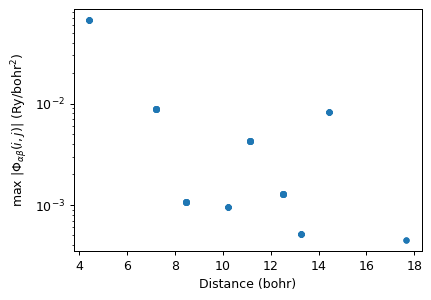

In [8]:
values, idx = fit2.get_fc(1, mode="origin")
pos = xcoord @ lavec                                     # Cartesian positions, bohr

blocks = {}
for v, (i3, j3) in zip(values, idx):
    blocks.setdefault((i3 // 3, j3 // 3), np.zeros((3, 3)))[i3 % 3, j3 % 3] = v

dist, strength = [], []
for (i, j), phi in blocks.items():
    if i == j:
        continue
    d = pos[j] - pos[i]
    d -= np.round(d @ np.linalg.inv(lavec)) @ lavec      # minimum image
    dist.append(np.linalg.norm(d))
    strength.append(np.abs(phi).max())

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.semilogy(dist, strength, "o", ms=4)
ax.set_xlabel("Distance (bohr)")
ax.set_ylabel(r"max $|\Phi_{\alpha\beta}(i,j)|$ (Ry/bohr$^2$)")
plt.show()